# Section 4 Extension: Non-Adversarial Opponents

This notebook studies the same 2x2 bandit setting from Section 4, but replaces the adversarial column player with structured opponents. The row-player algorithms are still UCB, EXP3, and OurAlg. The new opponents are uniform stochastic, Nash stochastic, and a Hedge-learning column player.

The goal is to check when the adversarial guarantees from the paper are actually needed. If the column player is less adversarial, simpler algorithms may perform much closer to OurAlg.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import numpy as np

from section4_non_adversarial import (
    A_GAME,
    plot_extension_average_payoff,
    plot_extension_non_adversarial,
    preset_config,
    print_summary,
    run_section4_non_adversarial,
)


## Experiment Setup

Use `quick` for a fast smoke test. Use `medium` or `paper-lite` for cleaner final plots.

In [2]:
preset = "paper-lite"  # options: "quick", "medium", "paper-lite"
seed = 42

np.random.seed(seed)
T_list, n_runs = preset_config(preset)

print(f"Preset: {preset}")
print(f"T values: {T_list}")
print(f"N runs: {n_runs}")
print(f"Game matrix:\n{A_GAME}")


Preset: paper-lite
T values: [10, 100, 1000, 10000, 100000]
N runs: 64
Game matrix:
[[0.66666667 0.        ]
 [0.         0.33333333]]


In [3]:
results = run_section4_non_adversarial(A_GAME, T_list, n_runs, verbose=True)



-- Uniform opponent ------------------------------------------
Uniform opponent -> all algorithms should be similar
  T=      10  UCB: R=    0.00, P=0.254  EXP3: R=    0.00, P=0.256  OurAlg: R=    0.00, P=0.256  
  T=     100  UCB: R=    0.00, P=0.239  EXP3: R=    0.00, P=0.275  OurAlg: R=    0.00, P=0.249  
  T=    1000  UCB: R=    0.00, P=0.225  EXP3: R=    0.00, P=0.303  OurAlg: R=    0.00, P=0.257  
  T=   10000  UCB: R=    0.00, P=0.223  EXP3: R=    0.00, P=0.323  OurAlg: R=    0.00, P=0.281  
  T=  100000  UCB: R=    0.00, P=0.222  EXP3: R=    0.00, P=0.330  OurAlg: R=    0.00, P=0.292  

-- Nash opponent ------------------------------------------
Nash opponent -> stable payoff around the game value is expected
  T=      10  UCB: R=    0.00, P=0.222  EXP3: R=    0.00, P=0.222  OurAlg: R=    0.00, P=0.222  
  T=     100  UCB: R=    0.00, P=0.222  EXP3: R=    0.00, P=0.222  OurAlg: R=    0.00, P=0.222  
  T=    1000  UCB: R=    0.00, P=0.222  EXP3: R=    0.00, P=0.222  OurAlg: R= 

## Plots

The first figure keeps the paper's log-regret style. The second figure adds average payoff, which is more informative when the opponent is not adversarial.


Figure saved -> plots\section4_non_adversarial_paper-lite.png

Figure saved -> plots\section4_non_adversarial_payoff_paper-lite.png


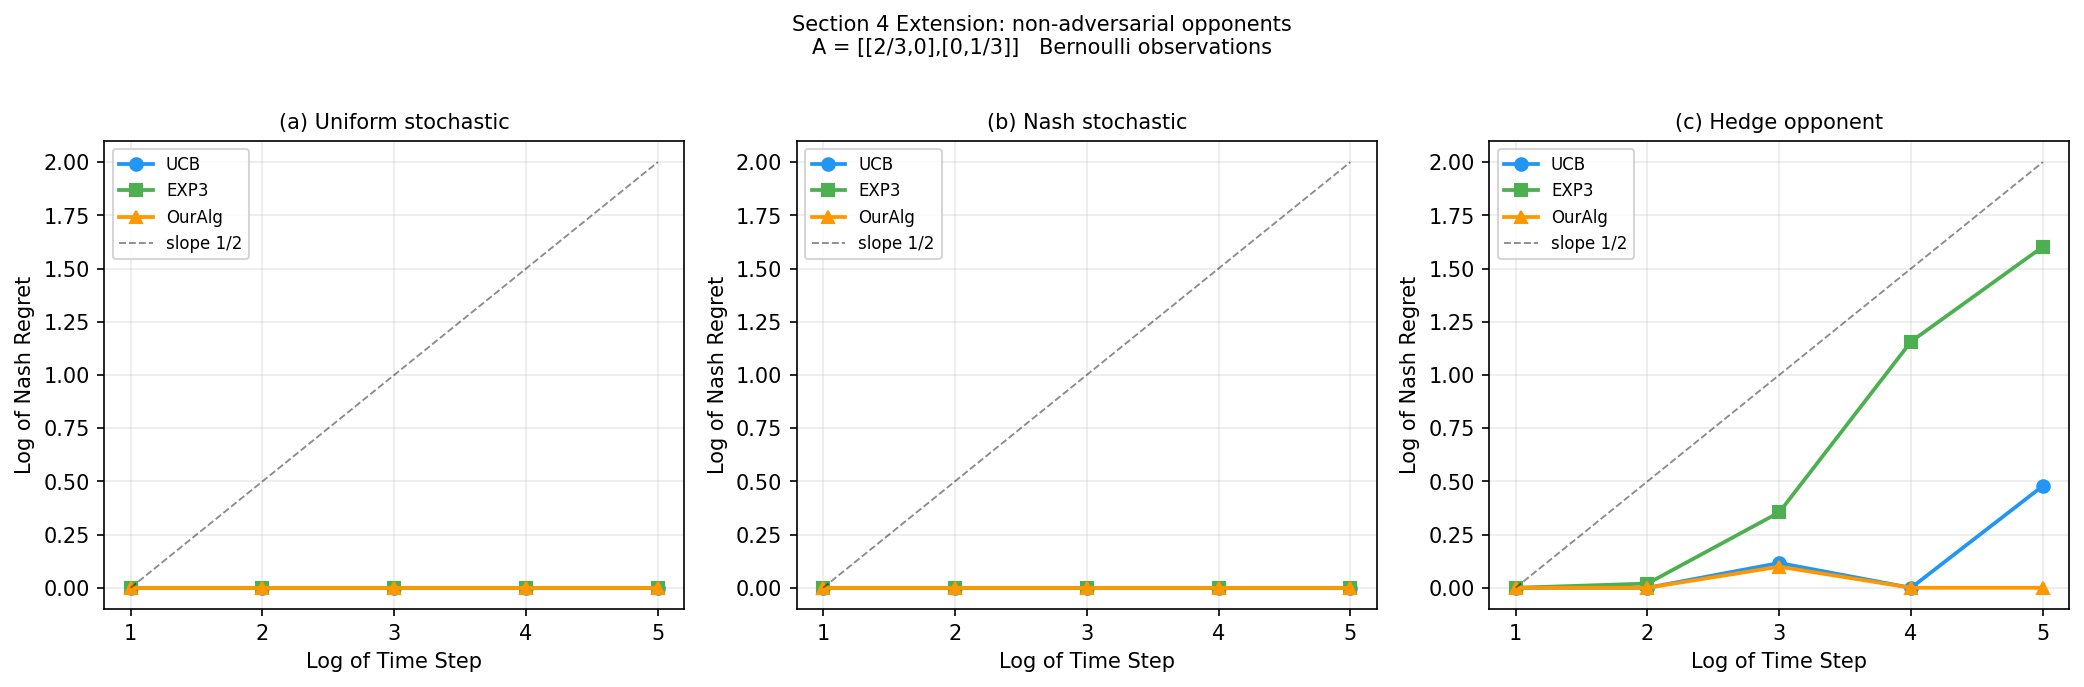

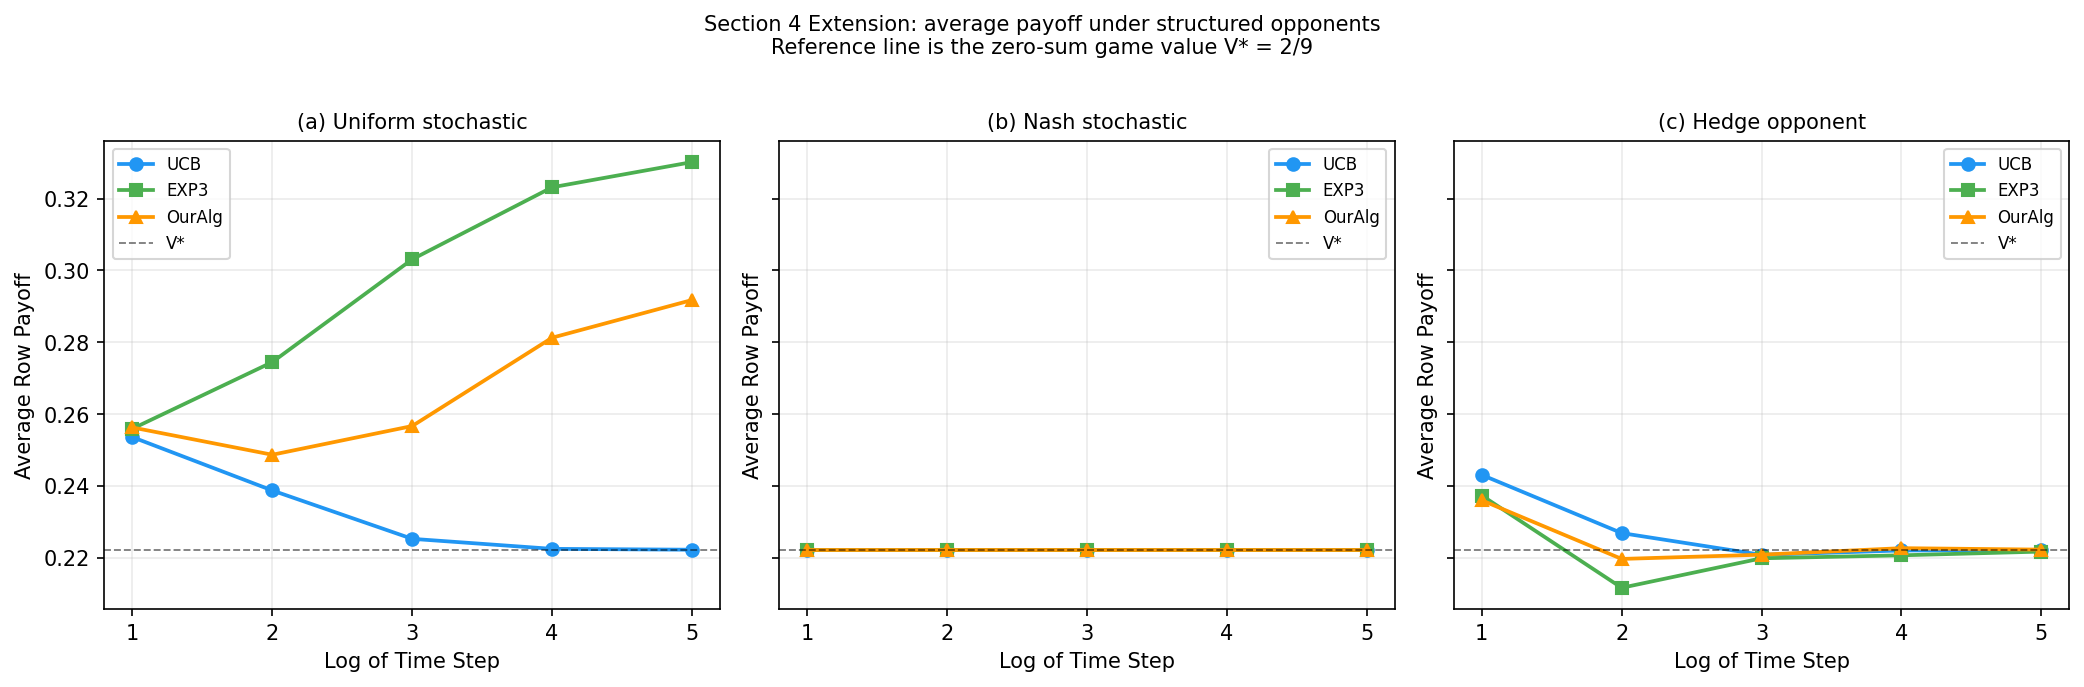

In [4]:
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

regret_path = plots_dir / f"section4_non_adversarial_{preset}.png"
payoff_path = plots_dir / f"section4_non_adversarial_payoff_{preset}.png"

plot_extension_non_adversarial(T_list, results, save_path=regret_path)
plot_extension_average_payoff(T_list, results, save_path=payoff_path)

display(Image(filename=str(regret_path)))
display(Image(filename=str(payoff_path)))


In [5]:
print_summary(T_list, results)



Final horizon summary
------------------------------------------------------------

Uniform opponent (T=100000)
 Algorithm    NashRegret   AvgPayoff      |x-x*|
       UCB          0.00      0.2223      0.0018
      EXP3          0.00      0.3301      0.6639
    OurAlg          0.00      0.2918      0.6611

Nash opponent (T=100000)
 Algorithm    NashRegret   AvgPayoff      |x-x*|
       UCB          0.00      0.2222      0.0159
      EXP3          0.00      0.2222      0.2423
    OurAlg          0.00      0.2222      0.0437

Hedge opponent (T=100000)
 Algorithm    NashRegret   AvgPayoff      |x-x*|
       UCB          3.01      0.2222      0.0012
      EXP3         40.03      0.2218      0.1933
    OurAlg          0.00      0.2224      0.0313


## Interpretation

- Uniform opponent: the column player is not adapting, so the three row algorithms should behave more similarly than in the adversarial experiment.
- Nash opponent: the column player is already playing the equilibrium mixture, so average payoff should stay close to the game value `V* = 2/9`.
- Hedge opponent: the column player learns from the row player's strategy, so this is more structured than the fixed stochastic cases but less hostile than a pure best-response adversary.

This extension tests whether the paper's adversarial guarantees are still necessary when the column player is stochastic or learning in a structured way.